In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_RAW = Path(r"C:\Users\syeds\OneDrive\Desktop\nboracle\nb_oracle\data\raw\store-sales-time-series-forecasting")

train = pd.read_csv(DATA_RAW / "train.csv", parse_dates=["date"])
holidays = pd.read_csv(DATA_RAW / "holidays_events.csv", parse_dates=["date"])

# Focus on Store 44
store44 = train[train.store_nbr == 44].copy()

# We'll build the model for BEVERAGES first, then test on others
bev = (store44[store44.family == "BEVERAGES"]
       .sort_values("date")
       .reset_index(drop=True))

print(f"Beverage sales data: {len(bev)} days")
print(f"Date range: {bev.date.min().date()} to {bev.date.max().date()}")

Beverage sales data: 1684 days
Date range: 2013-01-01 to 2017-08-15


In [3]:
def build_features(df, holidays_df):
    """
    Takes raw sales data and creates all the 'clues' (features)
    that XGBoost will use to make predictions.
    """
    data = df[["date", "sales"]].copy()
    data = data.set_index("date").sort_index()
    
    # ── CLUE GROUP 1: Recent sales history ───────────────────────
    # "How much have we been selling lately?"
    # shift(1) means "use yesterday's data, not today's" 
    # This prevents cheating — we can't use today's sales to predict today
    
    # Average sales over the last 7 days
    data["sales_avg_7d"] = data["sales"].shift(1).rolling(7).mean()
    
    # Average sales over the last 14 days
    data["sales_avg_14d"] = data["sales"].shift(1).rolling(14).mean()
    
    # Average sales over the last 28 days
    data["sales_avg_28d"] = data["sales"].shift(1).rolling(28).mean()
    
    # ── CLUE GROUP 2: Same day-of-week patterns ──────────────────
    # "What do Saturdays usually look like?"
    # This is similar to our baseline but as a feature, not the whole model
    
    # Sales from exactly 1 week ago
    data["sales_1w_ago"] = data["sales"].shift(7)
    
    # Sales from exactly 2 weeks ago
    data["sales_2w_ago"] = data["sales"].shift(14)
    
    # Average of same weekday over last 4 weeks
    data["sales_same_dow_avg_4w"] = (
        data["sales"].shift(7) + 
        data["sales"].shift(14) + 
        data["sales"].shift(21) + 
        data["sales"].shift(28)
    ) / 4
    
    # ── CLUE GROUP 3: Trend ──────────────────────────────────────
    # "Are sales going up or down recently?"
    
    # Difference between last week's avg and the week before that
    data["sales_trend"] = (
        data["sales"].shift(1).rolling(7).mean() - 
        data["sales"].shift(8).rolling(7).mean()
    )
    
    # ── CLUE GROUP 4: Calendar features ──────────────────────────
    # "What day/time is it?"
    
    # Day of week as a number (0=Monday, 6=Sunday)
    data["day_of_week"] = data.index.dayofweek
    
    # Month (1-12)
    data["month"] = data.index.month
    
    # Day of month (1-31) — useful for payday effects
    data["day_of_month"] = data.index.day
    
    # Is it a weekend? (Saturday=5, Sunday=6)
    data["is_weekend"] = data.index.dayofweek.isin([5, 6]).astype(int)
    
    # Is it around payday? (1st or 15th of the month)
    data["is_payday"] = data.index.day.isin([1, 2, 15, 16]).astype(int)
    
    # ── CLUE GROUP 5: Holiday effects ────────────────────────────
    # "Is there a holiday today or coming up?"
    
    # Get national holidays only
    national = holidays_df[holidays_df.locale == "National"]["date"].dt.date.values
    data["is_holiday"] = data.index.date
    data["is_holiday"] = data["is_holiday"].isin(national).astype(int)
    
    # ── CLUE GROUP 6: Promotion ──────────────────────────────────
    # Was this item on promotion?
    if "onpromotion" in df.columns:
        promo = df[["date", "onpromotion"]].copy().set_index("date").sort_index()
        data["on_promotion"] = promo["onpromotion"].fillna(0).astype(int)
    
    return data

# Build the features
bev_features = build_features(bev, holidays)

# Drop rows where we don't have enough history yet
# (first 28 days won't have 28-day averages)
bev_features = bev_features.dropna()

print(f"Rows with complete features: {len(bev_features)}")
print(f"\nFeatures we created:")
for col in bev_features.columns:
    if col != "sales":
        print(f"  • {col}")

Rows with complete features: 1656

Features we created:
  • sales_avg_7d
  • sales_avg_14d
  • sales_avg_28d
  • sales_1w_ago
  • sales_2w_ago
  • sales_same_dow_avg_4w
  • sales_trend
  • day_of_week
  • month
  • day_of_month
  • is_weekend
  • is_payday
  • is_holiday
  • on_promotion


In [4]:
def build_features(df, holidays_df):
    """
    Takes raw sales data and creates all the 'clues' (features)
    that XGBoost will use to make predictions.
    """
    data = df[["date", "sales"]].copy()
    data = data.set_index("date").sort_index()
    
    # ── CLUE GROUP 1: Recent sales history ───────────────────────
    # "How much have we been selling lately?"
    # shift(1) means "use yesterday's data, not today's" 
    # This prevents cheating — we can't use today's sales to predict today
    
    # Average sales over the last 7 days
    data["sales_avg_7d"] = data["sales"].shift(1).rolling(7).mean()
    
    # Average sales over the last 14 days
    data["sales_avg_14d"] = data["sales"].shift(1).rolling(14).mean()
    
    # Average sales over the last 28 days
    data["sales_avg_28d"] = data["sales"].shift(1).rolling(28).mean()
    
    # ── CLUE GROUP 2: Same day-of-week patterns ──────────────────
    # "What do Saturdays usually look like?"
    # This is similar to our baseline but as a feature, not the whole model
    
    # Sales from exactly 1 week ago
    data["sales_1w_ago"] = data["sales"].shift(7)
    
    # Sales from exactly 2 weeks ago
    data["sales_2w_ago"] = data["sales"].shift(14)
    
    # Average of same weekday over last 4 weeks
    data["sales_same_dow_avg_4w"] = (
        data["sales"].shift(7) + 
        data["sales"].shift(14) + 
        data["sales"].shift(21) + 
        data["sales"].shift(28)
    ) / 4
    
    # ── CLUE GROUP 3: Trend ──────────────────────────────────────
    # "Are sales going up or down recently?"
    
    # Difference between last week's avg and the week before that
    data["sales_trend"] = (
        data["sales"].shift(1).rolling(7).mean() - 
        data["sales"].shift(8).rolling(7).mean()
    )
    
    # ── CLUE GROUP 4: Calendar features ──────────────────────────
    # "What day/time is it?"
    
    # Day of week as a number (0=Monday, 6=Sunday)
    data["day_of_week"] = data.index.dayofweek
    
    # Month (1-12)
    data["month"] = data.index.month
    
    # Day of month (1-31) — useful for payday effects
    data["day_of_month"] = data.index.day
    
    # Is it a weekend? (Saturday=5, Sunday=6)
    data["is_weekend"] = data.index.dayofweek.isin([5, 6]).astype(int)
    
    # Is it around payday? (1st or 15th of the month)
    data["is_payday"] = data.index.day.isin([1, 2, 15, 16]).astype(int)
    
    # ── CLUE GROUP 5: Holiday effects ────────────────────────────
    # "Is there a holiday today or coming up?"
    
    # Get national holidays only
    national = holidays_df[holidays_df.locale == "National"]["date"].dt.date.values
    data["is_holiday"] = data.index.date
    data["is_holiday"] = data["is_holiday"].isin(national).astype(int)
    
    # ── CLUE GROUP 6: Promotion ──────────────────────────────────
    # Was this item on promotion?
    if "onpromotion" in df.columns:
        promo = df[["date", "onpromotion"]].copy().set_index("date").sort_index()
        data["on_promotion"] = promo["onpromotion"].fillna(0).astype(int)
    
    return data

# Build the features
bev_features = build_features(bev, holidays)

# Drop rows where we don't have enough history yet
# (first 28 days won't have 28-day averages)
bev_features = bev_features.dropna()

print(f"Rows with complete features: {len(bev_features)}")
print(f"\nFeatures we created:")
for col in bev_features.columns:
    if col != "sales":
        print(f"  • {col}")

Rows with complete features: 1656

Features we created:
  • sales_avg_7d
  • sales_avg_14d
  • sales_avg_28d
  • sales_1w_ago
  • sales_2w_ago
  • sales_same_dow_avg_4w
  • sales_trend
  • day_of_week
  • month
  • day_of_month
  • is_weekend
  • is_payday
  • is_holiday
  • on_promotion


In [5]:
# IMPORTANT: We split by DATE, not randomly.
# 
# Why? Because this is time series data. In real life, you can't 
# use future data to predict the past. If we randomly mixed dates,
# the model could "cheat" by learning from future patterns.
#
# We train on everything before July 15, 2017
# We test on everything after July 15, 2017 (last ~30 days)

SPLIT_DATE = "2017-07-15"

train_data = bev_features[bev_features.index < SPLIT_DATE]
test_data = bev_features[bev_features.index >= SPLIT_DATE]

# Separate features (the clues) from the target (what we're predicting)
# Features = every column EXCEPT "sales"
# Target = the "sales" column

feature_columns = [col for col in bev_features.columns if col != "sales"]

X_train = train_data[feature_columns]  # Training clues
y_train = train_data["sales"]          # Training answers

X_test = test_data[feature_columns]    # Test clues
y_test = test_data["sales"]            # Test answers (we'll compare against these)

print(f"Training: {len(X_train)} days (up to {SPLIT_DATE})")
print(f"Testing:  {len(X_test)} days (after {SPLIT_DATE})")
print(f"Features: {len(feature_columns)}")

Training: 1624 days (up to 2017-07-15)
Testing:  32 days (after 2017-07-15)
Features: 14


In [6]:
import xgboost as xgb

# Create the model with our settings from config.py
# (For now we'll set them directly here so you can see them)
model = xgb.XGBRegressor(
    objective="reg:tweedie",       # Special loss for sales data (handles zeros)
    tweedie_variance_power=1.6,
    n_estimators=500,              # Build up to 500 trees
    max_depth=6,                   # Each tree can be 6 levels deep
    learning_rate=0.05,            # Learn slowly (more accurate)
    subsample=0.8,                 # Use 80% of data per tree (prevents overfitting)
    colsample_bytree=0.7,         # Use 70% of features per tree
    min_child_weight=10,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,               # Makes results reproducible
    early_stopping_rounds=30,      # Stop if no improvement for 30 trees
)

# Train the model
# "eval_set" tells it to check progress on test data as it learns
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False  # Don't print every tree's progress
)

print(f"Training complete!")
print(f"Best iteration: {model.best_iteration} trees (out of max 500)")

Training complete!
Best iteration: 61 trees (out of max 500)


In [7]:
# Make predictions
predictions = model.predict(X_test)

# Predictions can't be negative (you can't sell -5 units)
predictions = np.maximum(predictions, 0)

# Calculate WMAPE (same metric we used for baseline)
def compute_wmape(actual, predicted):
    total_actual = np.sum(np.abs(actual))
    if total_actual == 0:
        return 0.0
    return np.sum(np.abs(actual - predicted)) / total_actual

xgb_wmape = compute_wmape(y_test.values, predictions)
baseline_wmape = 0.1502  # From our baseline notebook

print("=" * 50)
print("          RESULTS: XGBoost vs Baseline")
print("=" * 50)
print(f"  Baseline WMAPE:  {baseline_wmape:.4f} ({baseline_wmape*100:.1f}%)")
print(f"  XGBoost WMAPE:   {xgb_wmape:.4f} ({xgb_wmape*100:.1f}%)")
print(f"  Improvement:     {(baseline_wmape - xgb_wmape) / baseline_wmape * 100:.1f}%")
print("=" * 50)

if xgb_wmape < baseline_wmape:
    print("  ✅ XGBoost BEATS the baseline!")
else:
    print("  ❌ XGBoost did NOT beat the baseline. Features need work.")

          RESULTS: XGBoost vs Baseline
  Baseline WMAPE:  0.1502 (15.0%)
  XGBoost WMAPE:   0.1319 (13.2%)
  Improvement:     12.2%
  ✅ XGBoost BEATS the baseline!


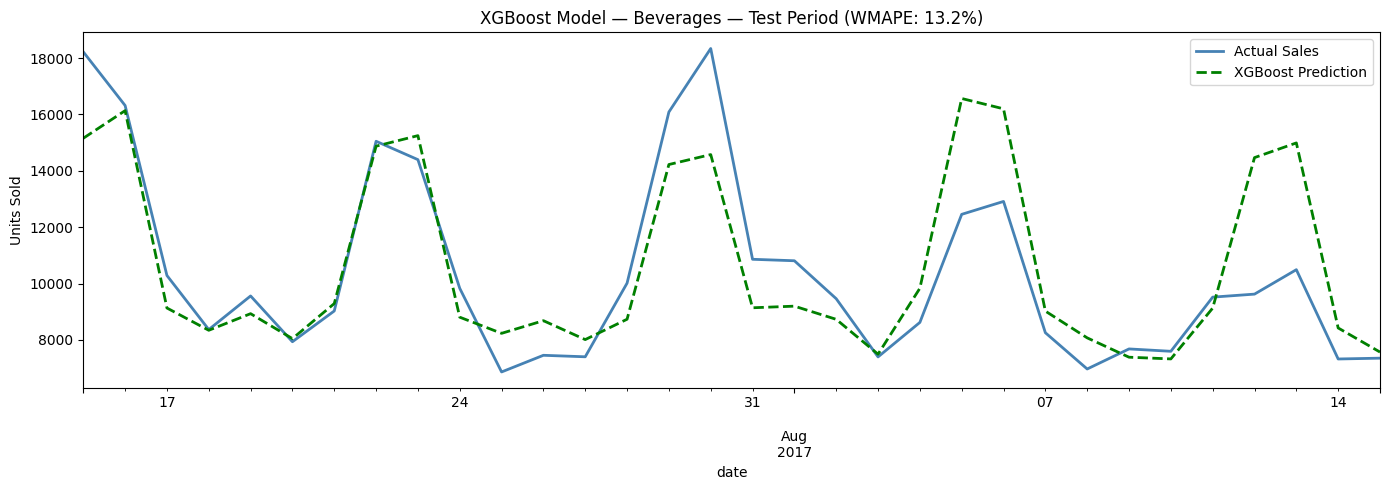

In [8]:
fig, ax = plt.subplots(figsize=(14, 5))

y_test.plot(ax=ax, label="Actual Sales", color="steelblue", linewidth=2)
pd.Series(predictions, index=y_test.index).plot(
    ax=ax, label="XGBoost Prediction", color="green", linewidth=2, linestyle="--")

ax.set_title(f"XGBoost Model — Beverages — Test Period (WMAPE: {xgb_wmape:.1%})")
ax.set_ylabel("Units Sold")
ax.legend()
plt.tight_layout()
plt.show()

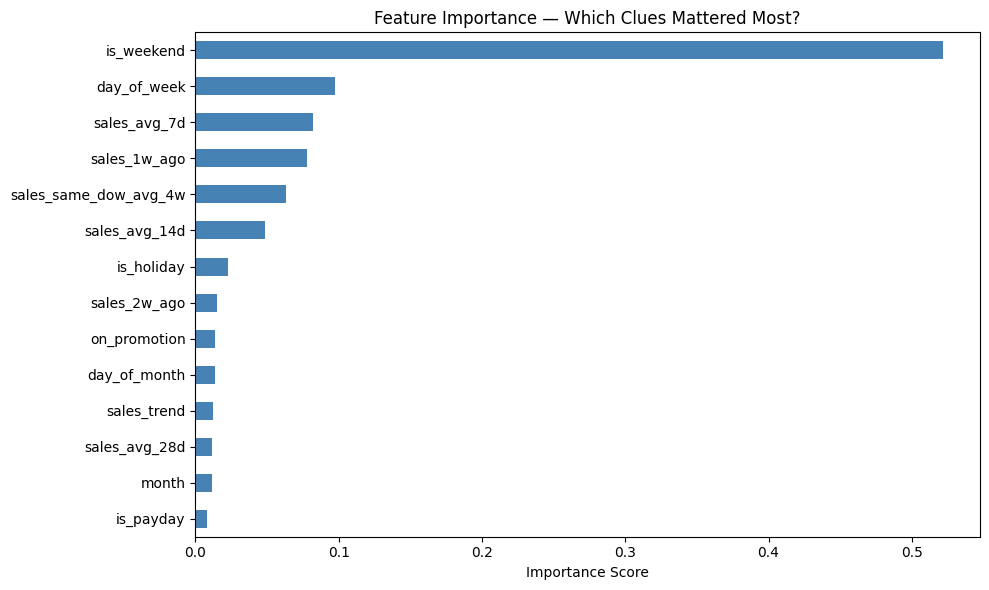


Top 5 most important features:
  • sales_same_dow_avg_4w: 0.063
  • sales_1w_ago: 0.078
  • sales_avg_7d: 0.082
  • day_of_week: 0.097
  • is_weekend: 0.522


In [9]:
# Feature importance: which clues did XGBoost find most useful?
importance = pd.Series(
    model.feature_importances_, 
    index=feature_columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
importance.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Feature Importance — Which Clues Mattered Most?")
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.show()

print("\nTop 5 most important features:")
for feat, score in importance.tail(5).items():
    print(f"  • {feat}: {score:.3f}")